# 02 — Inference: Text Query -> Highlighted Vehicle + Evaluation
**Project:** Text-to-Vehicle Retrieval & Tracking from CCTV footage

Uses the checkpoint produced by the companion **01 — Fine-Tuning** notebook. Combines the original Phase 4 (end-to-end demo) and Phase 5 (attribute re-ranking, interactive demo, formal evaluation):

1. Load the joint checkpoint + YOLO26/ByteTrack
2. Run detection -> tracking -> embedding -> ranking on a video
3. Attribute-based re-ranking (grounds ranking in color/type the model can actually see)
4. Interactive Gradio demo
5. Formal evaluation: held-out MRR/Recall@k + official `submission.json`

**Requires attached Kaggle datasets:** your trained joint-model checkpoint, CityFlow-NL.

## Part A — Setup

In [1]:
%%capture
!pip install -q -U ultralytics
!pip install -q supervision
!pip install -q timm
!pip install -q open_clip_torch
!pip install -q opencv-python-headless
!pip install -q gradio
print("Setup complete.")

In [2]:
import os, glob, json, random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import timm
import open_clip
import supervision as sv
from ultralytics import YOLO
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PROJECT_ROOT = "/kaggle/working/vehicle_nl_retrieval"
os.makedirs(os.path.join(PROJECT_ROOT, "outputs"), exist_ok=True)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Device: cuda


## Part B — Load checkpoint, CLIP, YOLO26 + ByteTrack

In [3]:
#name the model directory accordingly
ckpt_candidates = [p for p in glob.glob("/kaggle/input/datasets/*/*/*.pt", recursive=True) if "joint" in p.lower()]
assert ckpt_candidates, "No joint_model checkpoint found -- attach your trained checkpoint dataset via Add Input."
JOINT_CKPT_PATH = ckpt_candidates[0]
print("Using checkpoint:", JOINT_CKPT_PATH)


#you may use your prefered dataset of video as input
cityflow_candidates = [d for d in glob.glob("/kaggle/input/datasets/*/*") if "cityflow" in d.lower()]
assert cityflow_candidates, "No CityFlow-NL dataset found -- attach it via Add Input."
CITYFLOW_ROOT = cityflow_candidates[0]

DEFAULT_VIDEO_PATH = None
preferred = glob.glob(os.path.join(CITYFLOW_ROOT, "**/data/validation/S05/c020/vdo.avi"), recursive=True)
DEFAULT_VIDEO_PATH = sorted(preferred)[0]
print("Default video:", DEFAULT_VIDEO_PATH)

Using checkpoint: /kaggle/input/datasets/takayanagisensei/vehicle-text-joint-model/joint_model_epoch20.pt
Default video: /kaggle/input/datasets/takayanagisensei/cityflow-nl-aicity23/data/validation/S05/c020/vdo.avi


In [4]:
SHARED_DIM = 256

class ReIDModel(nn.Module):
    def __init__(self, num_classes, num_colors=None, num_types=None, embed_dim=2048):
        super().__init__()
        self.backbone = timm.create_model("resnet50", pretrained=True, num_classes=0, global_pool="avg")
        self.bnneck = nn.BatchNorm1d(embed_dim)
        self.bnneck.bias.requires_grad_(False)
        self.classifier = nn.Linear(embed_dim, num_classes, bias=False)
        self.color_classifier = nn.Linear(embed_dim, num_colors, bias=False) if num_colors else None
        self.type_classifier = nn.Linear(embed_dim, num_types, bias=False) if num_types else None

    def forward(self, x):
        feat = self.backbone(x)
        bn_feat = self.bnneck(feat)
        logits = self.classifier(bn_feat)
        color_logits = self.color_classifier(bn_feat) if self.color_classifier else None
        type_logits = self.type_classifier(bn_feat) if self.type_classifier else None
        return feat, bn_feat, logits, color_logits, type_logits


class VisualEncoder(nn.Module):
    def __init__(self, reid_model, in_dim=2048, out_dim=SHARED_DIM):
        super().__init__()
        self.reid_model = reid_model
        self.proj = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        _, bn_feat, _, _, _ = self.reid_model(x)
        return F.normalize(self.proj(bn_feat), dim=-1)


class TextEncoder(nn.Module):
    def __init__(self, clip_model, in_dim, out_dim=SHARED_DIM):
        super().__init__()
        self.clip_model = clip_model
        self.proj = nn.Linear(in_dim, out_dim)

    def forward(self, tokenized_text):
        text_feat = self.clip_model.encode_text(tokenized_text).float()
        return F.normalize(self.proj(text_feat), dim=-1)


clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
tokenizer = open_clip.get_tokenizer("ViT-B-32")
clip_model = clip_model.to(device).eval()
CLIP_TEXT_DIM = clip_model.text_projection.shape[1] if hasattr(clip_model, "text_projection") else 512

joint_ckpt = torch.load(JOINT_CKPT_PATH, map_location=device)
reid_sd = joint_ckpt["visual_encoder"]  # this is VisualEncoder's full state_dict, prefixed with "reid_model." / "proj."

# Infer the Re-ID architecture directly from the checkpoint's own weight shapes,
# instead of guessing num_classes -- this is what caused the 575 vs 576 mismatch.
num_classes_ckpt = reid_sd["reid_model.classifier.weight"].shape[0]
embed_dim_ckpt   = reid_sd["reid_model.classifier.weight"].shape[1]
num_colors_ckpt  = reid_sd["reid_model.color_classifier.weight"].shape[0] if "reid_model.color_classifier.weight" in reid_sd else None
num_types_ckpt   = reid_sd["reid_model.type_classifier.weight"].shape[0] if "reid_model.type_classifier.weight" in reid_sd else None

print(f"Inferred from checkpoint -- num_classes: {num_classes_ckpt}, embed_dim: {embed_dim_ckpt}, "
      f"num_colors: {num_colors_ckpt}, num_types: {num_types_ckpt}")

reid_backbone = ReIDModel(
    num_classes=num_classes_ckpt,
    num_colors=num_colors_ckpt,
    num_types=num_types_ckpt,
    embed_dim=embed_dim_ckpt,
)
visual_encoder = VisualEncoder(reid_backbone).to(device)
text_encoder = TextEncoder(clip_model, in_dim=CLIP_TEXT_DIM).to(device)

visual_encoder.load_state_dict(reid_sd)  # now a clean strict load, no mismatches
text_encoder.proj.load_state_dict(joint_ckpt["text_encoder_proj"])
visual_encoder.eval()
text_encoder.eval()


#You can use heavier model to detect more accurately in a crowdier scenario just add m,l,x etc instead of 's'
yolo_model = YOLO("yolo26m.pt")
VEHICLE_CLASS_IDS = [2, 3, 5, 7]
CONF_THRESHOLD = 0.35

img_transform_eval = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("All models loaded.")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Inferred from checkpoint -- num_classes: 575, embed_dim: 2048, num_colors: 10, num_types: 9


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

All models loaded.


## Part C — Attribute-based re-ranking

In [5]:
COLORS = ["black", "white", "gray", "silver", "red", "blue", "green", "yellow", "brown", "orange"]
TYPES = ["sedan", "suv", "pickup truck", "van", "hatchback", "bus", "truck", "motorcycle", "coupe", "mpv"]

#Just some common synonyms for better interpretation
TYPE_SYNONYMS = {
    "jeep": "suv", "crossover": "suv", "4x4": "suv",
    "pickup": "pickup truck", "lorry": "truck", "minivan": "van",
    "hatch": "hatchback", "bike": "motorcycle", "scooter": "motorcycle",
}

def parse_query_attributes(query_text):
    q = query_text.lower()
    found_color = next((c for c in COLORS if c in q), None)
    found_type = next((t for t in TYPES if t in q), None)
    if found_type is None:
        for syn, canon in TYPE_SYNONYMS.items():
            if syn in q:
                found_type = canon
                break
    return found_color, found_type


@torch.no_grad()
def clip_zero_shot_classify(crop_pil, candidates, prompt_template="a photo of a {} vehicle"):
    image_input = clip_preprocess(crop_pil).unsqueeze(0).to(device)
    text_inputs = tokenizer([prompt_template.format(c) for c in candidates]).to(device)
    image_feat = F.normalize(clip_model.encode_image(image_input).float(), dim=-1)
    text_feat = F.normalize(clip_model.encode_text(text_inputs).float(), dim=-1)
    sims = (image_feat @ text_feat.t())[0]
    best_idx = sims.argmax().item()
    return candidates[best_idx], sims[best_idx].item()


def attribute_rerank(ranked_tids_scores, track_crops, query_text, bonus=0.15, top_k=10):
    query_color, query_type = parse_query_attributes(query_text)
    if query_color is None and query_type is None:
        return ranked_tids_scores

    top = ranked_tids_scores[:top_k]
    rest = ranked_tids_scores[top_k:]
    adjusted = []
    for tid, score in top:
        crops = track_crops.get(tid, [])
        if not crops:
            adjusted.append((tid, score))
            continue
        sample_crop = crops[len(crops) // 2]
        new_score = score
        if query_color:
            pred_color, _ = clip_zero_shot_classify(sample_crop, COLORS, "a photo of a {} car")
            if pred_color == query_color:
                new_score += bonus
        if query_type:
            pred_type, _ = clip_zero_shot_classify(sample_crop, TYPES, "a photo of a {}")
            if pred_type == query_type:
                new_score += bonus
        adjusted.append((tid, new_score))
    adjusted.sort(key=lambda x: -x[1])
    return adjusted + rest


print(parse_query_attributes("a white sedan driving straight"))
print(parse_query_attributes("a black jeep turning left"))

('white', 'sedan')
('black', 'suv')


## Part D — Full pipeline function

In [6]:
@torch.no_grad()
def embed_track_crops(crops):
    if not crops:
        return None
    batch = torch.stack([img_transform_eval(c) for c in crops]).to(device)
    embeds = visual_encoder(batch)
    return F.normalize(embeds.mean(dim=0), dim=-1)


@torch.no_grad()
def embed_text(query):
    tokens = tokenizer([query]).to(device)
    return F.normalize(text_encoder(tokens)[0], dim=-1)


def run_pipeline(video_path, query_text, max_frames=600, use_attribute_rerank=True):
    tracker = sv.ByteTrack(track_activation_threshold=0.25, lost_track_buffer=30,
                            minimum_matching_threshold=0.8, frame_rate=25)

    track_crops, all_frame_detections = {}, []
    frame_idx = 0
    for frame in sv.get_video_frames_generator(source_path=video_path):
        if frame_idx >= max_frames:
            break
        result = yolo_model.predict(frame, conf=CONF_THRESHOLD, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)
        detections = detections[np.isin(detections.class_id, VEHICLE_CLASS_IDS)]
        detections = tracker.update_with_detections(detections)
        all_frame_detections.append((detections.xyxy.copy(), detections.tracker_id.copy(), detections.class_id.copy()))

        if frame_idx % 5 == 0:
            for box, tid in zip(detections.xyxy, detections.tracker_id):
                crops_so_far = track_crops.setdefault(int(tid), [])
                if len(crops_so_far) >= 8:
                    continue
                x1, y1, x2, y2 = box.astype(int)
                crop_np = frame[max(y1, 0):y2, max(x1, 0):x2]
                if crop_np.size == 0:
                    continue
                track_crops[int(tid)].append(Image.fromarray(cv2.cvtColor(crop_np, cv2.COLOR_BGR2RGB)))
        frame_idx += 1

    track_embeddings = {tid: e for tid, crops in track_crops.items()
                         if (e := embed_track_crops(crops)) is not None}
    if not track_embeddings:
        return None, [], "No vehicle tracks found -- try a longer max_frames or a different video.", None

    query_embed = embed_text(query_text)
    tids = list(track_embeddings.keys())
    sims = (torch.stack([track_embeddings[t] for t in tids]) @ query_embed).cpu().numpy()
    ranked = sorted(zip(tids, sims.tolist()), key=lambda x: -x[1])

    if use_attribute_rerank:
        ranked = attribute_rerank(ranked, track_crops, query_text)

    best_tid = ranked[0][0]

    output_path = os.path.join(PROJECT_ROOT, "outputs", "highlighted_output.mp4")
    video_info = sv.VideoInfo.from_video_path(video_path)
    MATCH_COLOR, OTHER_COLOR = (0, 0, 255), (160, 160, 160)
    with sv.VideoSink(target_path=output_path, video_info=video_info) as sink:
        for i, frame in enumerate(sv.get_video_frames_generator(source_path=video_path)):
            if i >= len(all_frame_detections):
                break
            xyxy, tracker_ids, _ = all_frame_detections[i]
            annotated = frame.copy()
            for box, tid in zip(xyxy, tracker_ids):
                x1, y1, x2, y2 = box.astype(int)
                is_match = int(tid) == best_tid
                color = MATCH_COLOR if is_match else OTHER_COLOR
                thickness = 4 if is_match else 1
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thickness)
                if is_match:
                    label = f"MATCH: {query_text}"
                    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                    cv2.rectangle(annotated, (x1, y1 - th - 10), (x1 + tw + 6, y1), color, -1)
                    cv2.putText(annotated, label, (x1 + 3, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            sink.write_frame(annotated)

    summary_lines = [f'Query: "{query_text}"', "", "Top matches:"]
    for tid, score in ranked[:5]:
        marker = " <-- best match" if tid == best_tid else ""
        summary_lines.append(f"  Track #{tid}: score={score:.4f}{marker}")

    return output_path, ranked[:5], "\n".join(summary_lines), track_crops


print("Pipeline function ready.")

Pipeline function ready.


## Part E — Quick single-query test

/tmp/ipykernel_58/1680101552.py:17: FutureWarning: The `ByteTrack` was deprecated since v0.28.0. It will be removed in v0.31.0.
  tracker = sv.ByteTrack(track_activation_threshold=0.25, lost_track_buffer=30,


Query: "a white sedan driving straight"

Top matches:
  Track #32: score=0.4817 <-- best match
  Track #7: score=0.3786
  Track #13: score=0.3690
  Track #15: score=0.3652
  Track #16: score=0.3290


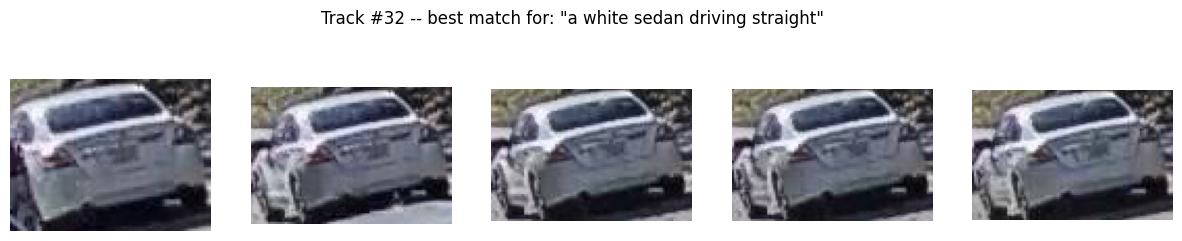

In [7]:
QUERY_TEXT = "a white sedan driving straight"  # <-- edit and re-run to try different queries
MAX_FRAMES = 600

output_path, ranked, summary, track_crops = run_pipeline(DEFAULT_VIDEO_PATH, QUERY_TEXT, MAX_FRAMES)
print(summary)

if ranked:
    best_tid = ranked[0][0]
    best_crops = track_crops[best_tid][:5]
    fig, axes = plt.subplots(1, len(best_crops), figsize=(3 * len(best_crops), 3))
    if len(best_crops) == 1:
        axes = [axes]
    for ax, crop in zip(axes, best_crops):
        ax.imshow(crop)
        ax.axis("off")
    plt.suptitle(f"Track #{best_tid} -- best match for: \"{QUERY_TEXT}\"")
    plt.show()

## Part F — Interactive Gradio demo

In [8]:
import gradio as gr

def gradio_run(uploaded_video, query_text, max_frames, use_rerank):
    video_path = uploaded_video if uploaded_video else DEFAULT_VIDEO_PATH
    if not query_text or not query_text.strip():
        return None, "Please enter a query, e.g. 'a white sedan driving straight'."
    output_path, _, summary, _ = run_pipeline(video_path, query_text.strip(), int(max_frames), use_rerank)
    return output_path, summary

with gr.Blocks(title="Text-to-Vehicle Retrieval Demo") as demo:
    gr.Markdown(
        "## Text-to-Vehicle Retrieval from CCTV Footage\n"
        "Type a description (color + vehicle type + action works best). "
        "Leave the video field empty to use the default CityFlow-NL sample."
    )
    with gr.Row():
        with gr.Column():
            video_input = gr.Video(label="Upload your own video (optional)")
            query_input = gr.Textbox(label="Text query", placeholder="a white sedan driving straight")
            max_frames_input = gr.Slider(100, 2000, value=600, step=100, label="Max frames to process")
            rerank_input = gr.Checkbox(value=True, label="Use attribute-based re-ranking")
            run_button = gr.Button("Find the vehicle", variant="primary")
        with gr.Column():
            video_output = gr.Video(label="Highlighted result")
            summary_output = gr.Textbox(label="Ranking summary", lines=8)

    run_button.click(fn=gradio_run,
                      inputs=[video_input, query_input, max_frames_input, rerank_input],
                      outputs=[video_output, summary_output])

demo.launch(share=True, debug=False)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a27c149e2e28d43115.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [15]:
from IPython.display import FileLink
!zip -r output.zip /kaggle/working/vehicle_nl_retrieval/outputs
FileLink(r'output.zip')

  adding: kaggle/working/vehicle_nl_retrieval/outputs/ (stored 0%)
  adding: kaggle/working/vehicle_nl_retrieval/outputs/highlighted_output.mp4 (deflated 0%)


/kaggle/working/output.zip